# Промышленность. Определение температуры сплава

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Необходимо построить модель, которая будет её предсказывать. 



**Ход выполнения работы**

1. Загрузка данных из всех файлов и выполнение их первичного осмотра.
2. Исследовательский анализ и предобработка данных для выбора параметров для обучения модели.
3. Выбор параметров для обучения моделей и объединение их в общий датафрейм.
4. Исследовательский анализ и предобработка данных объединённого датафрейма: исследование данных объединённого датафрейма, визуализация распределений признаков и при необходимости предобработка, корреляционный анализ, при необходимости генерация новых признаков.
5. Подготовка данных: разделение данных на две выборки, масштабирование и кодирование значений признаков.
6. Обучение моделей машинного обучения: обучение моделей нескльких видов с подбором как минимум двух гиперпараметров.
7. Выбор лучшей модели: проверка качества лучшей модели на тестовой выборке. Должно быть выполнено условие значение метрики MAE ≤ 6.8
8. Общий вывод и рекомендации заказчику

**Описание данных**

Данные состоят из нескольких файлов, полученных из разных источников:
* data_arc_new.csv — данные об электродах;
* data_bulk_new.csv — данные о подаче сыпучих материалов (объём);
* data_bulk_time_new.csv — данные о подаче сыпучих материалов (время);
* data_gas_new.csv — данные о продувке сплава газом;
* data_temp_new.csv — результаты измерения температуры;
* data_wire_new.csv — данные о проволочных материалах (объём);
* data_wire_time_new.csv — данные о проволочных материалах (время).

Файл data_arc_new.csv
* key — номер партии;
* Начало нагрева дугой — время начала нагрева;
* Конец нагрева дугой — время окончания нагрева;
* Активная мощность — значение активной мощности;
* Реактивная мощность — значение реактивной мощности.

Файл data_bulk_new.csv
* key — номер партии;
* Bulk 1 … Bulk 15 — объём подаваемого материала.

Файл data_bulk_time_new.csv
* key — номер партии;
* Bulk 1 … Bulk 15 — время подачи материала.

Файл data_gas_new.csv
* key — номер партии;
* Газ 1 — объём подаваемого газа.

Файл data_temp_new.csv
* key — номер партии;
* Время замера — время замера;
* Температура — значение температуры.

Файл data_wire_new.csv
* key — номер партии;
* Wire 1 … Wire 9 — объём подаваемых проволочных материалов.

Файл data_wire_time_new.csv
* key — номер партии;
* Wire 1 … Wire 9 — время подачи проволочных материалов.

Во всех файлах столбец key содержит номер партии. В файлах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

In [1]:
!pip install -U scikit-learn -q
!pip install phik -q
!pip install shap -q
!pip install optuna -q
!pip install optuna-integration -q

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

# подготовка данных
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (FunctionTransformer, 
                                   StandardScaler, 
                                   MinMaxScaler)
from sklearn.impute import SimpleImputer

# пайплан
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# метрика оценки качества модели
from sklearn.metrics import mean_absolute_error as MAE

# модели
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor

#import shap

import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix

In [3]:
RANDOM_STATE = 61125
TEST_SIZE = 0.25

## Загрузка данных

### Данные об электродах

In [4]:
df_arc = pd.read_csv('https://code.s3.yandex.net/datasets/data_arc_new.csv',
                     parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой']
                    )
df_arc.head(5)

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


In [5]:
df_arc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   key                   14876 non-null  int64         
 1   Начало нагрева дугой  14876 non-null  datetime64[ns]
 2   Конец нагрева дугой   14876 non-null  datetime64[ns]
 3   Активная мощность     14876 non-null  float64       
 4   Реактивная мощность   14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 581.2 KB


### Данные о подаче сыпучих материалов (объём)

In [6]:
df_bulk = pd.read_csv('https://code.s3.yandex.net/datasets/data_bulk_new.csv')
df_bulk.head(5)

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


In [7]:
df_bulk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.2 KB


### Данные о подаче сыпучих материалов (время)

In [8]:
df_bulk_time = pd.read_csv('https://code.s3.yandex.net/datasets/data_bulk_time_new.csv', 
                           parse_dates=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
                          )
df_bulk_time.head(5)

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaT,NaT,NaT,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:53:30,NaT,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaT,NaT,NaT,2019-05-03 12:32:39,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:27:13,NaT,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,NaT,NaT,NaT,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:58:00,NaT,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,2019-05-03 13:34:12,2019-05-03 13:30:47


In [9]:
df_bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   key      3129 non-null   int64         
 1   Bulk 1   252 non-null    datetime64[ns]
 2   Bulk 2   22 non-null     datetime64[ns]
 3   Bulk 3   1298 non-null   datetime64[ns]
 4   Bulk 4   1014 non-null   datetime64[ns]
 5   Bulk 5   77 non-null     datetime64[ns]
 6   Bulk 6   576 non-null    datetime64[ns]
 7   Bulk 7   25 non-null     datetime64[ns]
 8   Bulk 8   1 non-null      datetime64[ns]
 9   Bulk 9   19 non-null     datetime64[ns]
 10  Bulk 10  176 non-null    datetime64[ns]
 11  Bulk 11  177 non-null    datetime64[ns]
 12  Bulk 12  2450 non-null   datetime64[ns]
 13  Bulk 13  18 non-null     datetime64[ns]
 14  Bulk 14  2806 non-null   datetime64[ns]
 15  Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](15), int64(1)
memory usage: 391.2 KB


### Данные о продувке сплава газом

In [10]:
df_gas = pd.read_csv('https://code.s3.yandex.net/datasets/data_gas_new.csv')
df_gas.head(5)

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [11]:
df_gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


### Результаты измерения температуры

In [12]:
df_temp = pd.read_csv('https://code.s3.yandex.net/datasets/data_temp_new.csv',
                      parse_dates=['Время замера']
                     )
df_temp.head(5)

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


In [13]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           18092 non-null  int64         
 1   Время замера  18092 non-null  datetime64[ns]
 2   Температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 424.2 KB


### Данные о проволочных материалах (объём)

In [14]:
df_wire = pd.read_csv('https://code.s3.yandex.net/datasets/data_wire_new.csv')
df_wire.head(5)

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df_wire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


### Данные о проволочных материалах (время)

In [16]:
df_wire_time = pd.read_csv('https://code.s3.yandex.net/datasets/data_wire_time_new.csv', 
                           parse_dates=[1,2,3,4,5,6,7,8,9]
                          )
df_wire_time.head(5)

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,3,2019-05-03 12:11:46,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
3,4,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaT,NaT,NaT,NaT,NaT,NaT,NaT


In [17]:
df_wire_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   Wire 1  3055 non-null   datetime64[ns]
 2   Wire 2  1079 non-null   datetime64[ns]
 3   Wire 3  63 non-null     datetime64[ns]
 4   Wire 4  14 non-null     datetime64[ns]
 5   Wire 5  1 non-null      datetime64[ns]
 6   Wire 6  73 non-null     datetime64[ns]
 7   Wire 7  11 non-null     datetime64[ns]
 8   Wire 8  19 non-null     datetime64[ns]
 9   Wire 9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9), int64(1)
memory usage: 240.8 KB


### Вывод

Данные импортированы в датафреймы. Колонки с временем загружены с типом datetime для удобства дальнейшей обработки. По первоначальному обзору видно соответствие полученных данных описанию.

## Исследовательский анализ и предобработка данных

In [18]:
def column_names(df):
    df.columns = df.columns.str.lower()
    df.columns = df.columns.str.replace(' ', '_')
    return df

In [19]:
list_of_dfs = [df_arc, df_bulk, df_bulk_time, df_gas, df_temp, df_wire, df_wire_time]

for df in list_of_dfs:
    df = column_names(df)
    print(df.sample(3))

       key начало_нагрева_дугой конец_нагрева_дугой  активная_мощность  \
570    125  2019-05-08 07:35:13 2019-05-08 07:39:09           0.301262   
7010  1520  2019-06-29 16:04:14 2019-06-29 16:07:15           0.458329   
5299  1149  2019-06-16 06:57:09 2019-06-16 06:58:18           0.460413   

      реактивная_мощность  
570              0.191663  
7010             0.385962  
5299             0.343780  
       key  bulk_1  bulk_2  bulk_3  bulk_4  bulk_5  bulk_6  bulk_7  bulk_8  \
68      78     NaN     NaN   149.0     NaN     NaN    87.0     NaN     NaN   
1305  1357     NaN     NaN     NaN   231.0     NaN     NaN     NaN     NaN   
737    771     NaN     NaN     NaN    25.0     NaN     NaN     NaN     NaN   

      bulk_9  bulk_10  bulk_11  bulk_12  bulk_13  bulk_14  bulk_15  
68       NaN      NaN      NaN    205.0      NaN    109.0    203.0  
1305     NaN      NaN      NaN    409.0      NaN    205.0    206.0  
737      NaN      NaN      NaN      NaN      NaN    205.0      NaN  
  

### Анализ данных об электродах

In [20]:
df_arc.duplicated().sum()

0

In [21]:
df_arc.describe()

,key,активная_мощность,реактивная_мощность
count,14876.000000,14876.000000,14876.000000
mean,1615.220422,0.662752,0.438986
std,934.571502,0.258885,5.873485
min,1.000000,0.223120,-715.479924
25%,806.000000,0.467115,0.337175
50%,1617.000000,0.599587,0.441639
75%,2429.000000,0.830070,0.608201
max,3241.000000,1.463773,1.270284


In [22]:
df_arc[df_arc['начало_нагрева_дугой'] >= df_arc['конец_нагрева_дугой']]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность


In [23]:
df_arc[df_arc['реактивная_мощность'] < 0]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924


In [24]:
df_arc[df_arc['key'] == 2116]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
9778,2116,2019-07-28 02:07:12,2019-07-28 02:09:14,0.787549,0.693881
9779,2116,2019-07-28 02:13:10,2019-07-28 02:15:25,0.580263,0.411498
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924
9781,2116,2019-07-28 02:29:11,2019-07-28 02:30:18,0.563641,0.408513


In [25]:
df_gas[df_gas['key'] == 2116]

,key,газ_1
2113,2116,11.582547


In [26]:
df_temp[df_temp['key'] == 2116]

,key,время_замера,температура
11877,2116,2019-07-28 02:07:02,1579.0
11878,2116,2019-07-28 02:13:00,1574.0
11879,2116,2019-07-28 02:21:58,1578.0
11880,2116,2019-07-28 02:29:01,1575.0
11881,2116,2019-07-28 02:35:36,1578.0


Выявлен аномальный выбрас значения ресктивной мощности для одного замера ковша с номером 2116. Данные в других таблицах по данному ковшу есть и может понадобится количество или продолжительность нагрева дугой, поэтому выполню замену отртцательного значения на среднее значение реактивной мощности данного ковша (данное значение не нарушит закономерности отношения реактивной мощности к активной).

In [27]:
df_arc.loc[9780, 'реактивная_мощность'] = df_arc[((df_arc['key'] == 2116)
                                                  & (df_arc['реактивная_мощность'] > 0))]['реактивная_мощность'].mean()
df_arc[df_arc['key'] == 2116]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
9778,2116,2019-07-28 02:07:12,2019-07-28 02:09:14,0.787549,0.693881
9779,2116,2019-07-28 02:13:10,2019-07-28 02:15:25,0.580263,0.411498
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,0.504631
9781,2116,2019-07-28 02:29:11,2019-07-28 02:30:18,0.563641,0.408513


In [28]:
df_arc_mean_power = df_arc[['key', 'активная_мощность', 'реактивная_мощность']].groupby('key').mean().reset_index()
df_arc_mean_power.head(5)

,key,активная_мощность,реактивная_мощность
0,1,0.607346,0.428564
1,2,0.534852,0.363339
2,3,0.812728,0.587491
3,4,0.676622,0.514248
4,5,0.563238,0.421998


In [29]:
def box_hist_plots(data, param_name, ax_name):
    fig, (ax_box, ax_hist) = plt.subplots(nrows=2, ncols=1, figsize=(9,9))
    sns.boxplot(data=data, orient='h', ax=ax_box)
    ax_box.set_title(f'Разброс значений параметра\n {param_name}', fontsize=14)
    ax_box.set_xlabel(f'{ax_name}')
    ax_box.grid(axis='x')
    
    sns.histplot(data=data,
                 stat='density',
                 common_norm=False,
                 ax=ax_hist)
    ax_hist.axvline(data.mean(), c='red', ls='-', lw=2.5, label='Среднее')
    ax_hist.axvline(data.median(), c='green', ls='--', lw=2.5, label='Медиана')
    ax_hist.set_xlabel(f'{ax_name}')
    ax_hist.set_ylabel('Плотность распределения')
    ax_hist.set_title(f'Распределение значений параметра\n {param_name}', fontsize=14)
    ax_hist.legend()
    ax_hist.grid()
    fig.tight_layout()
    plt.show()

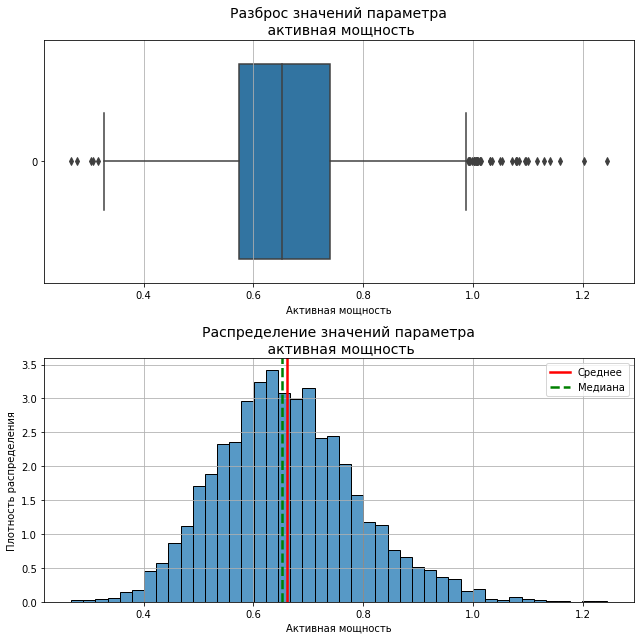

In [30]:
box_hist_plots(df_arc_mean_power['активная_мощность'], 'активная мощность', 'Активная мощность')

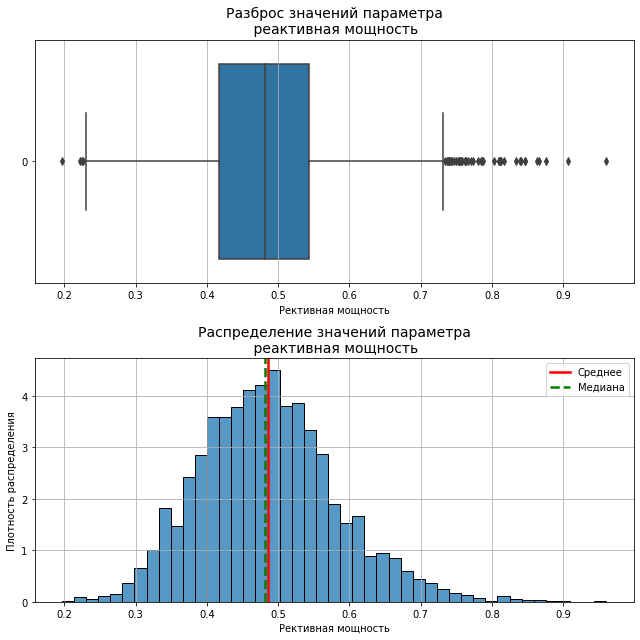

In [31]:
box_hist_plots(df_arc_mean_power['реактивная_мощность'], 'реактивная мощность', 'Рективная мощность')

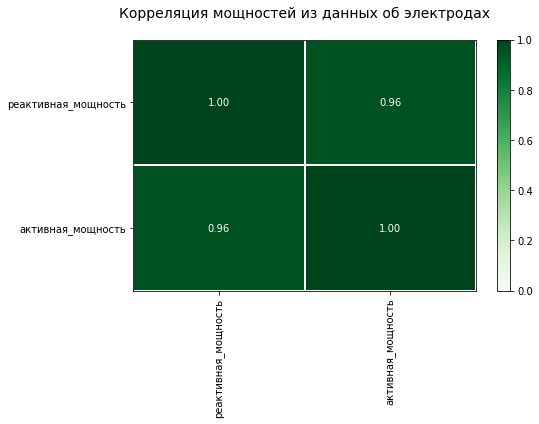

In [32]:
interval_cols = ['активная_мощность','реактивная_мощность']
phik_overview = phik_matrix(df_arc_mean_power[['активная_мощность','реактивная_мощность']], interval_cols=interval_cols)
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title='Корреляция мощностей из данных об электродах\n',
    fontsize_factor=1.0,
    figsize=(8, 6)
)

Добавление полной мощности для использования в модли вместо 2 коррелирующих параметров активная_мощность и реактивная_мощность

In [33]:
df_arc.head(6)

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691
5,2,2019-05-03 11:34:14,2019-05-03 11:36:31,0.381124,0.220351


In [34]:
df_arc['full_power'] = (df_arc['активная_мощность']**2 + df_arc['реактивная_мощность']**2)**0.5
df_arc.head(6)

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,full_power
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,0.371123
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,0.902319
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,0.722536
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,0.642824
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,1.079934
5,2,2019-05-03 11:34:14,2019-05-03 11:36:31,0.381124,0.220351,0.440239


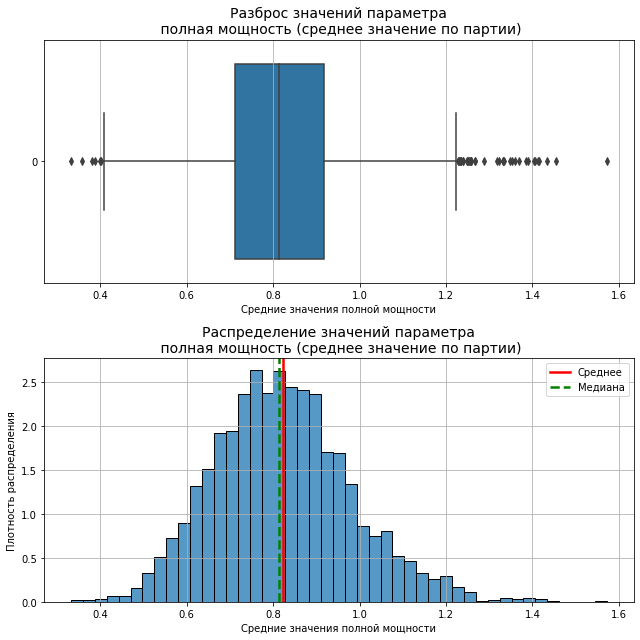

In [35]:
box_hist_plots(df_arc.groupby('key')['full_power'].mean().reset_index(drop=True), 
               'полная мощность (среднее значение по партии)', 'Средние значения полной мощности')

In [36]:
df_arc['arc_heating_time_diff'] = (df_arc['конец_нагрева_дугой'] - df_arc['начало_нагрева_дугой']).dt.total_seconds()
df_arc.head(8)

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,full_power,arc_heating_time_diff
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,0.371123,228.0
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,0.902319,185.0
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,0.722536,172.0
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,0.642824,365.0
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,1.079934,148.0
5,2,2019-05-03 11:34:14,2019-05-03 11:36:31,0.381124,0.220351,0.440239,137.0
6,2,2019-05-03 11:38:50,2019-05-03 11:44:28,0.261665,0.205527,0.332731,338.0
7,2,2019-05-03 11:46:19,2019-05-03 11:48:25,0.710297,0.484962,0.860064,126.0


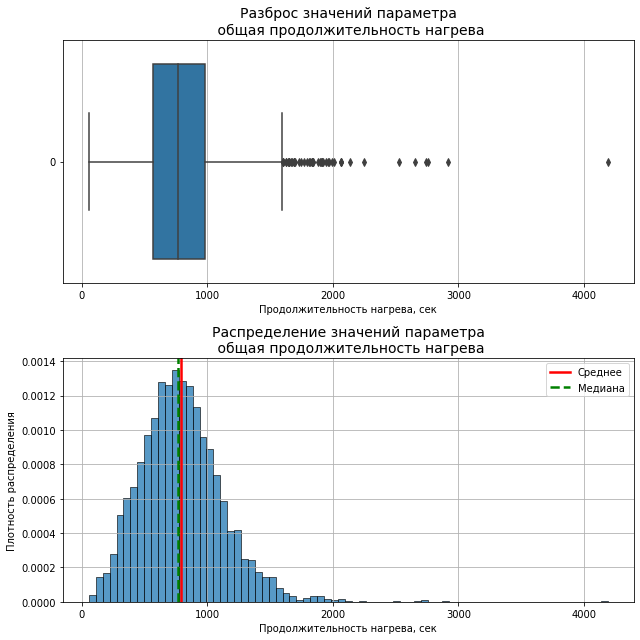

In [37]:
box_hist_plots(df_arc.groupby('key')['arc_heating_time_diff'].sum().reset_index(drop=True), 
               'общая продолжительность нагрева', 'Продолжительность нагрева, сек')

In [38]:
df_arc_final = df_arc.groupby('key').agg({'full_power':'mean', 
                                          'arc_heating_time_diff':'sum',
                                          'key':'count'})
df_arc_final = df_arc_final.rename(columns = {'arc_heating_time_diff':'arc_heating_time_total', 'key':'arc_count'})
df_arc_final.head(6)

,full_power,arc_heating_time_total,arc_count
key,,,
1,0.743747,1098.0,5
2,0.647087,811.0,4
3,1.003845,655.0,5
4,0.850010,741.0,4
5,0.704245,869.0,4
6,0.828269,952.0,4


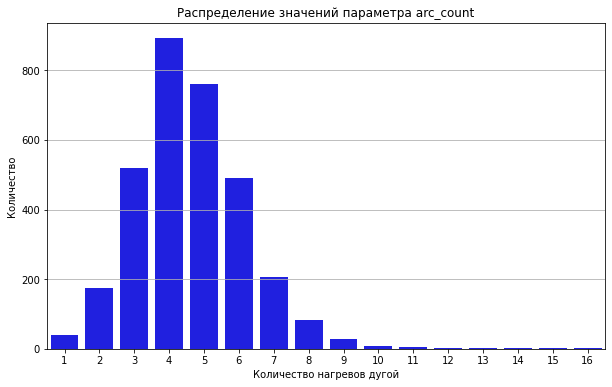

In [39]:
plt.figure(figsize = (10, 6))
sns.countplot(x=df_arc_final['arc_count'], color='blue')
plt.title('Распределение значений параметра arc_count')
plt.xlabel('Количество нагревов дугой')
plt.ylabel('Количество')
plt.grid(axis='y')
plt.show()

In [40]:
df_arc_final.describe()

,full_power,arc_heating_time_total,arc_count
count,3214.000000,3214.000000,3214.000000
mean,0.821568,794.579029,4.628500
std,0.160110,332.448622,1.608647
min,0.331897,57.000000,1.000000
25%,0.711251,571.000000,4.000000
50%,0.812409,770.000000,4.000000
75%,0.916602,983.000000,6.000000
max,1.572238,4189.000000,16.000000


In [41]:
print('Количество записей с уникальным key в данных об электродах:', df_arc_final['full_power'].count())

Количество записей с уникальным key в данных об электродах: 3214


Все добавленные и выбранные для модели параметры имеют нормальное распределение. Средние и медианные значения близки, но есть выбросы в больших значениях для всех 3 параметров.

Из данных об электродах были взяты полная мощность, вычисленная из активной и реактивной мощностей, общее время нагрева дугой и количество нагревов дугой. В рамках выявления аномальных выбросов было обнаружено отрицательное значение реактивной мощности и исправлено на среднее значение.

### Анализ данных о подаче сыпучих материалов

In [42]:
df_bulk.duplicated().sum()

0

In [43]:
df_bulk['key'].duplicated().sum()

0

In [44]:
df_bulk_time.duplicated().sum()

0

In [45]:
df_bulk_time['key'].duplicated().sum()

0

In [46]:
df_bulk.describe()

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,933.337642,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,1.000000,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


In [47]:
print('Количество записей с уникальным key в данных подаче сыпучих материалов (объём):', df_bulk['key'].count())

Количество записей с уникальным key в данных подаче сыпучих материалов (объём): 3129


In [48]:
print('Количество записей с уникальным key в данных подаче сыпучих материалов (время):', df_bulk_time['key'].count())

Количество записей с уникальным key в данных подаче сыпучих материалов (время): 3129


In [49]:
df_bulk_final = df_bulk.set_index('key')
df_bulk_time_final = df_bulk_time.set_index('key')

In [50]:
for bulk in df_bulk_final.columns:
    print(f'{bulk}:', df_bulk_final[bulk].count())

bulk_1: 252
bulk_2: 22
bulk_3: 1298
bulk_4: 1014
bulk_5: 77
bulk_6: 576
bulk_7: 25
bulk_8: 1
bulk_9: 19
bulk_10: 176
bulk_11: 177
bulk_12: 2450
bulk_13: 18
bulk_14: 2806
bulk_15: 2248


Распределения наиболее часто используемых сыпучих материалов:

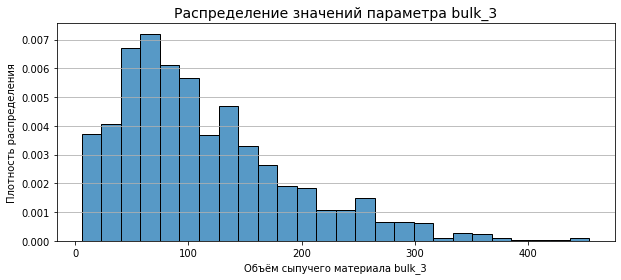

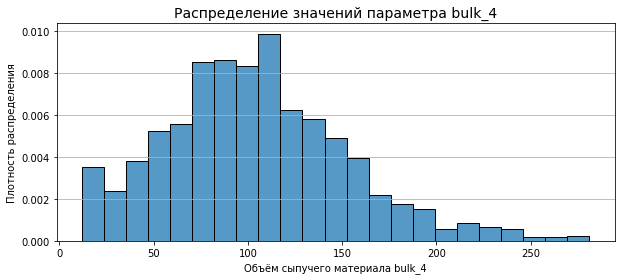

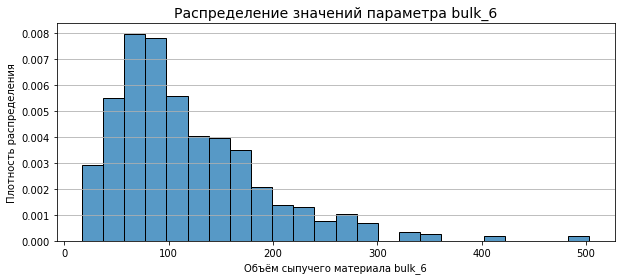

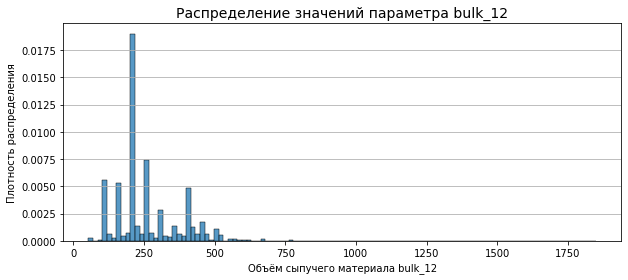

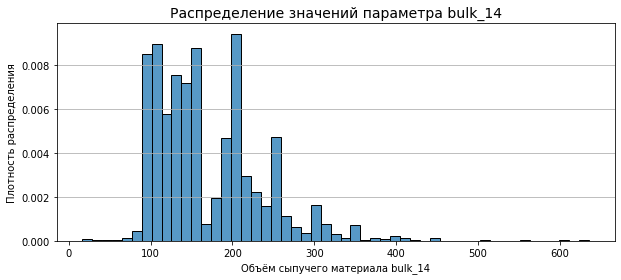

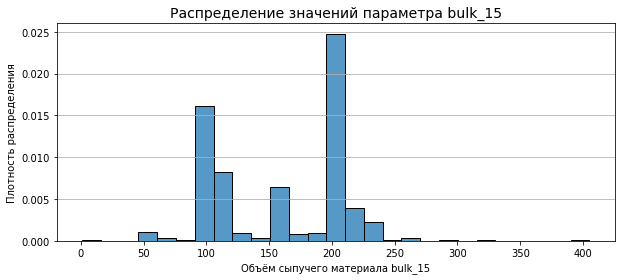

In [51]:
for bulk in df_bulk_final.columns:
    if df_bulk_final[bulk].count() > 500:
        plt.figure(figsize = (10, 4))
        sns.histplot(data=df_bulk_final[bulk],
                     stat='density',
                     common_norm=False)
        plt.title(f'Распределение значений параметра {bulk}', fontsize=14)
        plt.xlabel(f'Объём сыпучего материала {bulk}')
        plt.ylabel('Плотность распределения')
        plt.grid(axis='y')
        plt.show()

In [52]:
df_bulk_final['bulk_count'] = df_bulk_final.apply(lambda x: x.count(), axis=1)
df_bulk_final.sample(3)

,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,bulk_count
key,,,,,,,,,,,,,,,,
719,NaN,NaN,211.0,77.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,152.0,157.0,5
1759,46.0,NaN,212.0,NaN,33.0,121.0,NaN,NaN,NaN,NaN,NaN,410.0,NaN,251.0,205.0,7
578,NaN,NaN,53.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,157.0,152.0,4


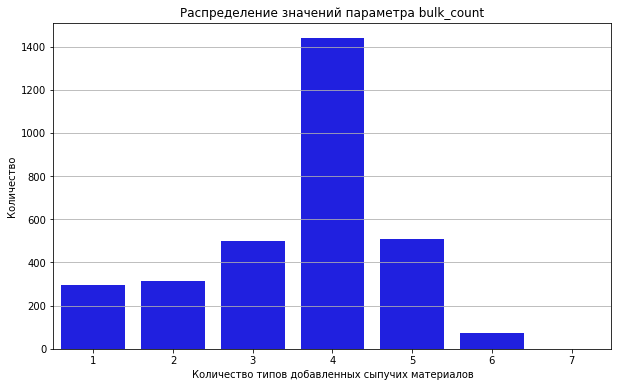

In [53]:
plt.figure(figsize = (10, 6))
sns.countplot(x=df_bulk_final['bulk_count'], color='blue')
plt.title('Распределение значений параметра bulk_count')
plt.xlabel('Количество типов добавленных сыпучих материалов')
plt.ylabel('Количество')
plt.grid(axis='y')
plt.show()

В основном в партию добавляют материалы bulk_14, bulk_12, bulk_15, bulk_3 и bulk_4 и чаще всего используют 4 сыпучих материала.

Из данных о подаче сыпучих материалов были взяты только данные об объёме материалов, значения времени подачи избыточны для модели. По нескольких партиям была выполнена проверка нахождения дат и времени подачи материалов в рамках дат и времени замеров температур, которая не выявила несоответствий.

### Анализ данных о продувке сплава газом

In [54]:
df_gas.duplicated().sum()

0

In [55]:
df_gas.describe()

,key,газ_1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


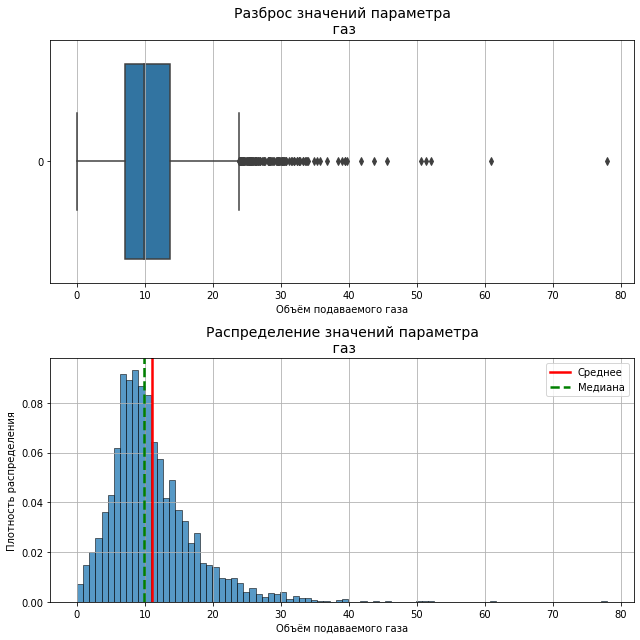

In [56]:
box_hist_plots(df_gas['газ_1'], 'газ', 'Объём подаваемого газа')

In [57]:
df_gas[df_gas['газ_1'] == 0]

,key,газ_1


In [58]:
df_gas_final = df_gas.set_index('key').rename(columns={'газ_1':'gas'})
df_gas_final.sample(4)

,gas
key,
2706,8.928267
755,9.173081
1142,30.157628
2632,6.533869


In [59]:
print('Количество записей с уникальным key в данных о продувке сплава газом:', df_gas_final['gas'].count())

Количество записей с уникальным key в данных о продувке сплава газом: 3239


В значениях газа нет пропусков. Объём подаваемого газа имеет нормальное распределение со сдвигом влево, есть выбросы в больших значениях. Газ является неотъемлемой частью процесса, поэтому в итоговый датафрейм для обучения моделей будут взяты только те партии, которые имеют значение параметра газ.

### Анализ данных о результатах измерения температуры

In [60]:
df_temp.duplicated().sum()

0

In [61]:
df_temp.loc[df_temp.groupby('key')['время_замера'].idxmax()].count()

key             3216
время_замера    3216
температура     2477
dtype: int64

In [62]:
df_temp_last = (df_temp
                 .loc[df_temp.groupby('key')['время_замера'].idxmax()]
#                 .set_index('key')
                 .rename(columns = {'время_замера':'temp_time', 'температура':'temp_last'}))
df_temp_last.sample(6)

,key,temp_time,temp_last
4915,871,2019-06-06 11:22:33,1588.0
4714,839,2019-06-05 04:31:12,1579.0
79,14,2019-05-03 20:44:15,1606.0
9976,1783,2019-07-08 15:31:47,1589.0
14010,2512,2019-08-11 00:10:49,NaN
1320,234,2019-05-12 13:14:08,1590.0


In [63]:
df_temp_last[df_temp_last['temp_last'].isna()].count()

key          739
temp_time    739
temp_last      0
dtype: int64

In [64]:
df_temp_last[df_temp_last['temp_last'] <= 1400].count()

key          0
temp_time    0
temp_last    0
dtype: int64

In [65]:
df_temp_last = df_temp_last.reset_index(drop=True)

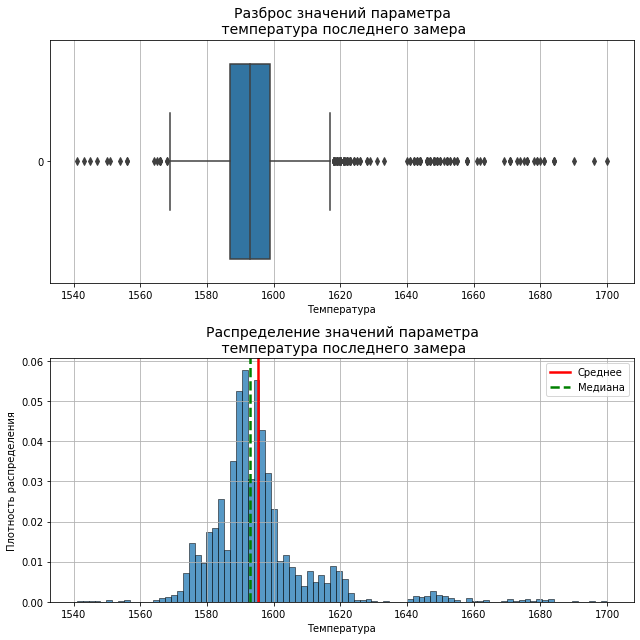

In [66]:
box_hist_plots(df_temp_last['temp_last'], 'температура последнего замера', 'Температура')

In [67]:
df_temp_last = df_temp_last.dropna().set_index('key')
df_temp_last.sample(4)

,temp_time,temp_last
key,,
652,2019-05-28 22:14:28,1599.0
848,2019-06-05 13:19:40,1614.0
341,2019-05-16 16:16:34,1584.0
1604,2019-07-02 16:04:20,1579.0


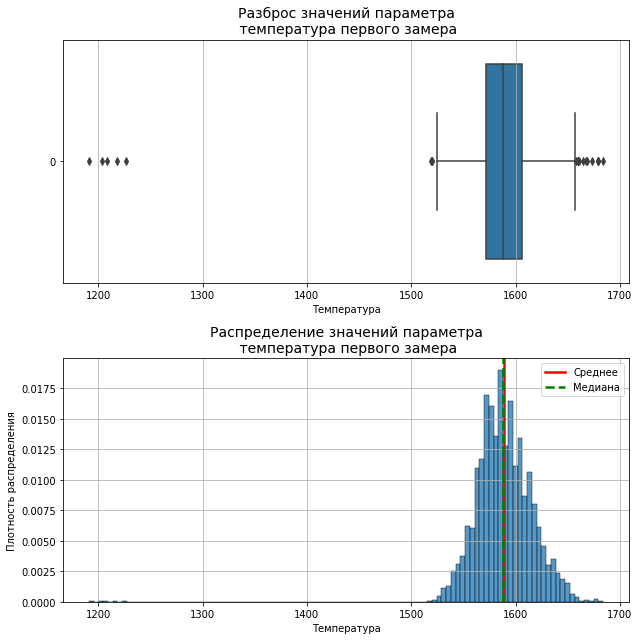

In [68]:
df_temp_first = (df_temp
                 .loc[df_temp.groupby('key')['время_замера'].idxmin()]
                 .rename(columns = {'время_замера':'temp_time', 'температура':'temp_first'})
                 .reset_index(drop=True))

box_hist_plots(df_temp_first['temp_first'], 'температура первого замера', 'Температура')

In [69]:
df_temp_first[df_temp_first['temp_first'].isna()].count()

key           0
temp_time     0
temp_first    0
dtype: int64

In [70]:
df_temp_first[df_temp_first['temp_first'] <= 1400]

,key,temp_time,temp_first
855,867,2019-06-06 08:03:39,1191.0
1201,1214,2019-06-18 08:01:03,1208.0
1604,1619,2019-07-03 02:34:41,1218.0
2036,2052,2019-07-25 08:49:15,1227.0
2538,2561,2019-08-12 18:49:29,1204.0


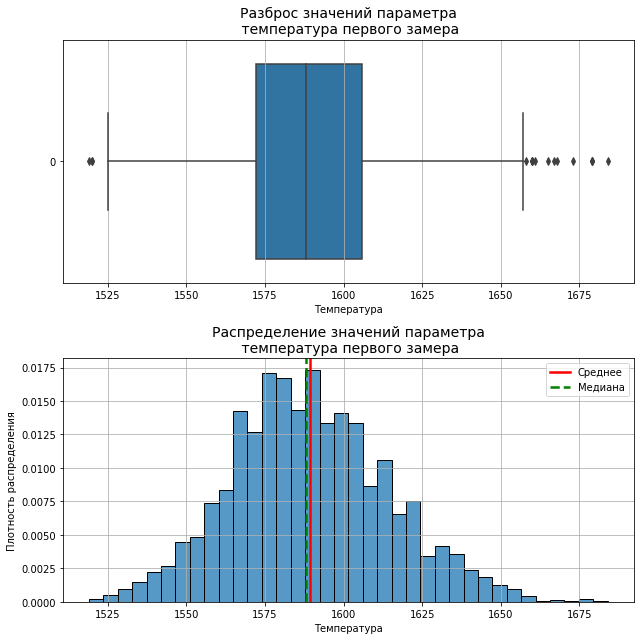

In [71]:
df_temp_first = df_temp_first[df_temp_first['temp_first'] >= 1400].reset_index(drop=True)

box_hist_plots(df_temp_first['temp_first'], 'температура первого замера', 'Температура')

In [72]:
df_temp_first = df_temp_first.set_index('key')
df_temp_first.sample(4)

,temp_time,temp_first
key,,
2904,2019-08-25 19:51:53,1558.0
2351,2019-08-04 23:09:54,1596.0
138,2019-05-08 21:44:41,1612.0
1898,2019-07-13 05:05:26,1551.0


In [73]:
df_temp_first.count()

temp_time     3211
temp_first    3211
dtype: int64

In [74]:
df_temp_final = df_temp_last[['temp_last']].join(df_temp_first['temp_first'], how='inner')
df_temp_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2473 entries, 1 to 2499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   temp_last   2473 non-null   float64
 1   temp_first  2473 non-null   float64
dtypes: float64(2)
memory usage: 58.0 KB


In [75]:
df_temp_final#.sample(4)

,temp_last,temp_first
key,,
1,1613.0,1571.0
2,1602.0,1581.0
3,1599.0,1596.0
4,1625.0,1601.0
5,1602.0,1576.0
...,...,...
2495,1591.0,1570.0
2496,1591.0,1554.0
2497,1589.0,1571.0


Из данных о результатах измерения температуры были взяты температуры первого и последнего замера. В температурах первого замера были удалены выбросы с некорректными значениями температур (ниже 1400) в количестве 5 замеров. В температурах последнего замера были удалены партии с отсутствующими значениями, т.к. данный параметр является целевым и без его значения не получится обучить и проверить модель. В итоговой таблице осталось 2473 записей.

### Анализ данных о проволочных материалах

In [76]:
df_wire.duplicated().sum()

0

In [77]:
df_wire['key'].duplicated().sum()

0

In [78]:
df_wire_time.duplicated().sum()

0

In [79]:
df_wire_time['key'].duplicated().sum()

0

In [80]:
df_wire.describe()

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
count,3081.000000,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,1623.426485,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,932.996726,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.000000,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,823.000000,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,1619.000000,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,2434.000000,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


In [81]:
print('Количество записей с уникальным key в данных подаче проволочных материалов (объём):', df_wire['key'].count())

Количество записей с уникальным key в данных подаче проволочных материалов (объём): 3081


In [82]:
print('Количество записей с уникальным key в данных подаче проволочных материалов (объём):', df_wire_time['key'].count())

Количество записей с уникальным key в данных подаче проволочных материалов (объём): 3081


In [83]:
df_wire_final = df_wire.set_index('key')
#df_wire_time_final = df_wire_time.set_index('key')

for wire in df_wire_final.columns:
    print(f'{wire}:', df_wire_final[wire].count())

wire_1: 3055
wire_2: 1079
wire_3: 63
wire_4: 14
wire_5: 1
wire_6: 73
wire_7: 11
wire_8: 19
wire_9: 29


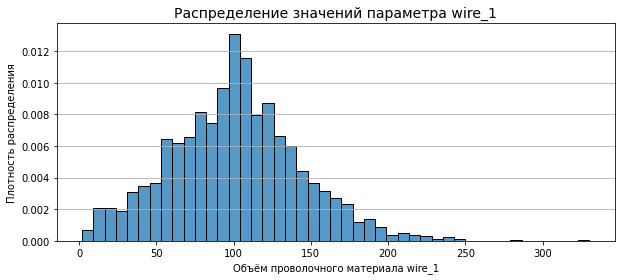

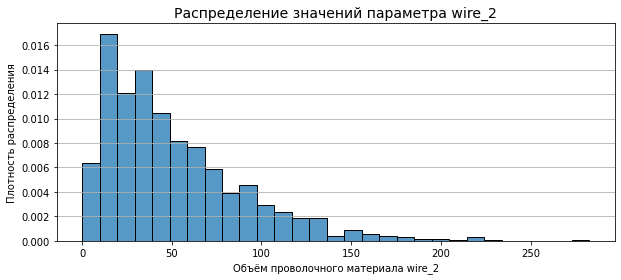

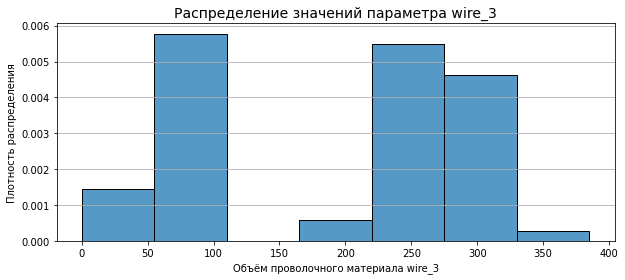

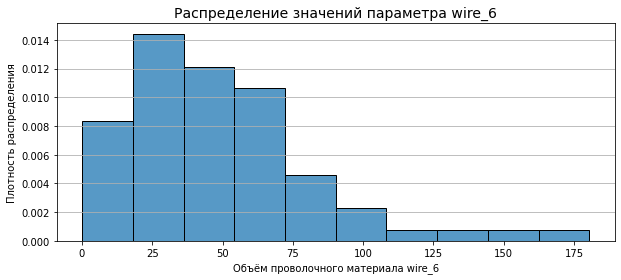

In [84]:
for wire in df_wire_final.columns:
    if df_wire_final[wire].count() > 50:
        plt.figure(figsize = (10, 4))
        sns.histplot(data=df_wire_final[wire],
                     stat='density',
                     common_norm=False)
        plt.title(f'Распределение значений параметра {wire}', fontsize=14)
        plt.xlabel(f'Объём проволочного материала {wire}')
        plt.ylabel('Плотность распределения')
        plt.grid(axis='y')
        plt.show()

In [85]:
df_wire_final['wire_count'] = df_wire_final.apply(lambda x: x.count(), axis=1)
df_wire_final.sample(3)

,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,wire_count
key,,,,,,,,,,
2609,100.070877,88.097359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
793,120.229195,19.121441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
666,64.162796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


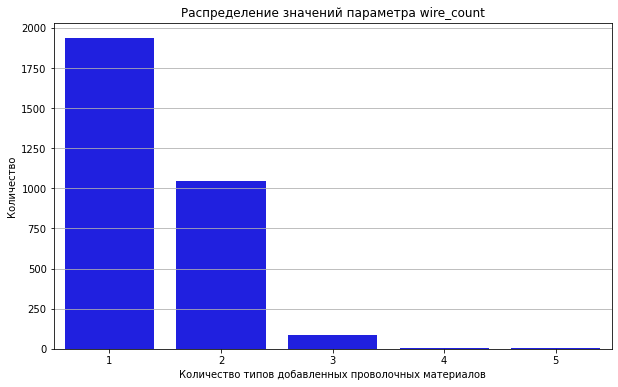

In [86]:
plt.figure(figsize = (10, 6))
sns.countplot(x=df_wire_final['wire_count'], color='blue')
plt.title('Распределение значений параметра wire_count')
plt.xlabel('Количество типов добавленных проволочных материалов')
plt.ylabel('Количество')
plt.grid(axis='y')
plt.show()

В основном в партию добавляют материалы wire_1 и wire_2 и чаще всего проволочных материалов не больше 2. Объём подаваемого материала имеет нормальное распределение со сдвигом влево, характерны выбросы в больших значениях.

Из данных о проволочных материалах были взяты только данные об объёме материалов, значения времени подачи избыточны для модели. По нескольких партиям была выполнена проверка нахождения дат и времени подачи материалов в рамках дат и времени замеров температур, которая не выявила несоответствий.

### Вывод

Для каждого полученного файла был выполнен анализ данных и определение признаков для финального датафрейма. Все файлы были проверены на дубликаты, аномальные выбросы, некорректные значения, наличие обязательных данных (значение финального замера температуры партии, которое является целевым).

В данных об электродах взяты параметры:
- full_power - полная мощность
- arc_heating_time_total - общее время нагрева
- arc_count - количество нагревов электродами
- Количество записей 3214

В данных о подаче сыпучих материалов взяты параметры:
- bulk_1 ... bulk_15 - объём добавленных сыпучих материалов
- bulk_count - количество типов добавленных сыпучих материалов
- Количество записей 3129

В данных о продувке сплава газом взяты параметры:
- gas - объём подаваемого для продувки газа
- Количество записей 3239

В данных о результатах измерения темпераьуры взяты параметры:
- temp_last - температура последнего замера (целевой признак)
- temp_first - температура первого замера
- Количество записей 2473

В данных о проволочных материалах взяты параметры:
- wire_1 ... wire_9 - объём добавленных проволочных материалов
- wire_count - количество типов добавленных проволочных материалов
- Количество записей 3081

## Объединение данных

In [87]:
df_final = df_temp_final.join([df_gas_final, df_arc_final, df_bulk_final, df_wire_final], how='inner')
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2325 entries, 1 to 2499
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   temp_last               2325 non-null   float64
 1   temp_first              2325 non-null   float64
 2   gas                     2325 non-null   float64
 3   full_power              2325 non-null   float64
 4   arc_heating_time_total  2325 non-null   float64
 5   arc_count               2325 non-null   int64  
 6   bulk_1                  199 non-null    float64
 7   bulk_2                  13 non-null     float64
 8   bulk_3                  958 non-null    float64
 9   bulk_4                  811 non-null    float64
 10  bulk_5                  53 non-null     float64
 11  bulk_6                  438 non-null    float64
 12  bulk_7                  13 non-null     float64
 13  bulk_8                  1 non-null      float64
 14  bulk_9                  13 non-null     

In [88]:
df_final.head(5)

,temp_last,temp_first,gas,full_power,arc_heating_time_total,arc_count,bulk_1,bulk_2,bulk_3,bulk_4,...,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,wire_count
key,,,,,,,,,,,,,,,,,,,,,
1,1613.0,1571.0,29.749986,0.743747,1098.0,5,NaN,NaN,NaN,43.0,...,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,1602.0,1581.0,12.555561,0.647087,811.0,4,NaN,NaN,NaN,73.0,...,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,1599.0,1596.0,28.554793,1.003845,655.0,5,NaN,NaN,NaN,34.0,...,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,1625.0,1601.0,18.841219,0.850010,741.0,4,NaN,NaN,NaN,81.0,...,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
5,1602.0,1576.0,5.413692,0.704245,869.0,4,NaN,NaN,NaN,78.0,...,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


Выбранные на предыдущем шаге данные были объеденены в общий датафрейм при помощи inner join (были собраны только те партии, которые присутствовали во всех итоговых датафреймах предыдущего шага)

## Исследовательский анализ и предобработка данных объединённого датафрейма

In [89]:
df_final.describe()

,temp_last,temp_first,gas,full_power,arc_heating_time_total,arc_count,bulk_1,bulk_2,bulk_3,bulk_4,...,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,wire_count
count,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,199.000000,13.000000,958.000000,811.000000,...,2302.000000,809.000000,39.000000,12.000000,0.0,45.000000,4.000000,13.000000,24.000000,2325.000000
mean,1593.366022,1587.365161,11.378942,0.825643,808.035269,4.696344,40.115578,254.846154,114.786013,107.023428,...,103.435430,50.597164,193.182538,59.496235,NaN,50.659374,3.703414,55.772561,30.773167,1.396989
std,11.209581,23.623144,6.395632,0.160377,340.829330,1.605930,18.226180,25.973853,77.383675,49.074553,...,42.525047,39.800935,100.867783,30.804638,NaN,37.743040,3.818433,20.235591,15.210141,0.564505
min,1541.000000,1519.000000,0.008399,0.331897,57.000000,1.000000,10.000000,228.000000,6.000000,13.000000,...,1.918800,0.030160,0.144144,24.148801,NaN,0.137280,0.234208,45.076721,4.622800,1.000000
25%,1587.000000,1571.000000,7.282948,0.714331,581.000000,4.000000,27.000000,242.000000,57.250000,73.000000,...,75.042236,20.180161,93.189102,38.347402,NaN,25.053600,0.849004,46.002319,20.802601,1.000000
50%,1593.000000,1587.000000,10.100950,0.818378,778.000000,5.000000,33.000000,248.000000,96.500000,105.000000,...,102.030235,40.112801,236.972740,49.661561,NaN,40.085762,3.044704,46.187439,30.066399,1.000000
75%,1598.000000,1603.000000,14.217691,0.921276,993.000000,6.000000,46.500000,258.000000,152.000000,136.500000,...,128.178188,70.061684,277.068801,84.755579,NaN,65.036400,5.899114,46.279999,40.495001,2.000000
max,1653.000000,1660.000000,77.995040,1.572238,4189.000000,16.000000,185.000000,325.000000,454.000000,281.000000,...,330.314424,282.780152,385.008668,113.231044,NaN,180.454575,8.490040,102.762401,62.025600,5.000000


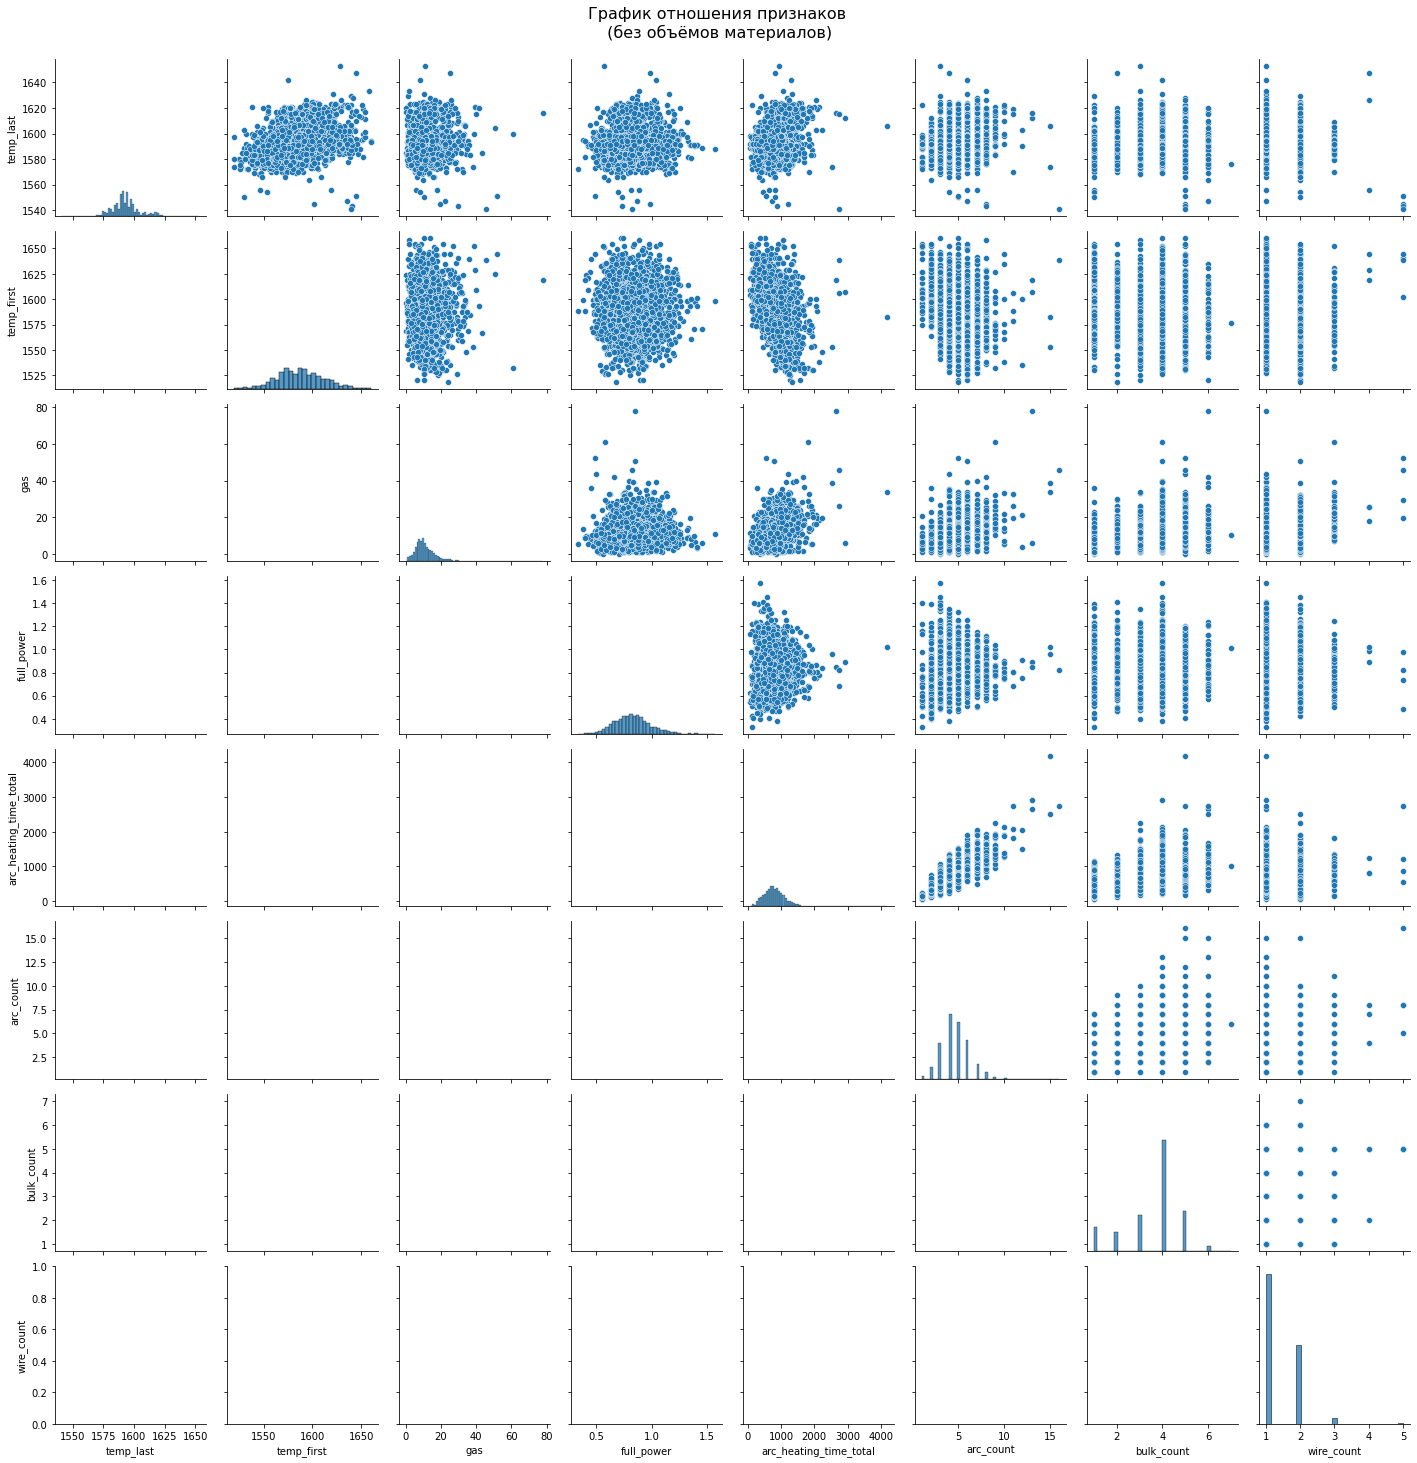

In [90]:
figsize=(10, 10)
g = sns.PairGrid(df_final[['temp_last', 'temp_first', 'gas', 'full_power', 
                           'arc_heating_time_total', 'arc_count', 'bulk_count', 'wire_count']])
g.map_diag(sns.histplot)
g.map_upper(sns.scatterplot)
g.fig.suptitle('График отношения признаков\n (без объёмов материалов)', fontsize=16, y=1.02)
plt.show()

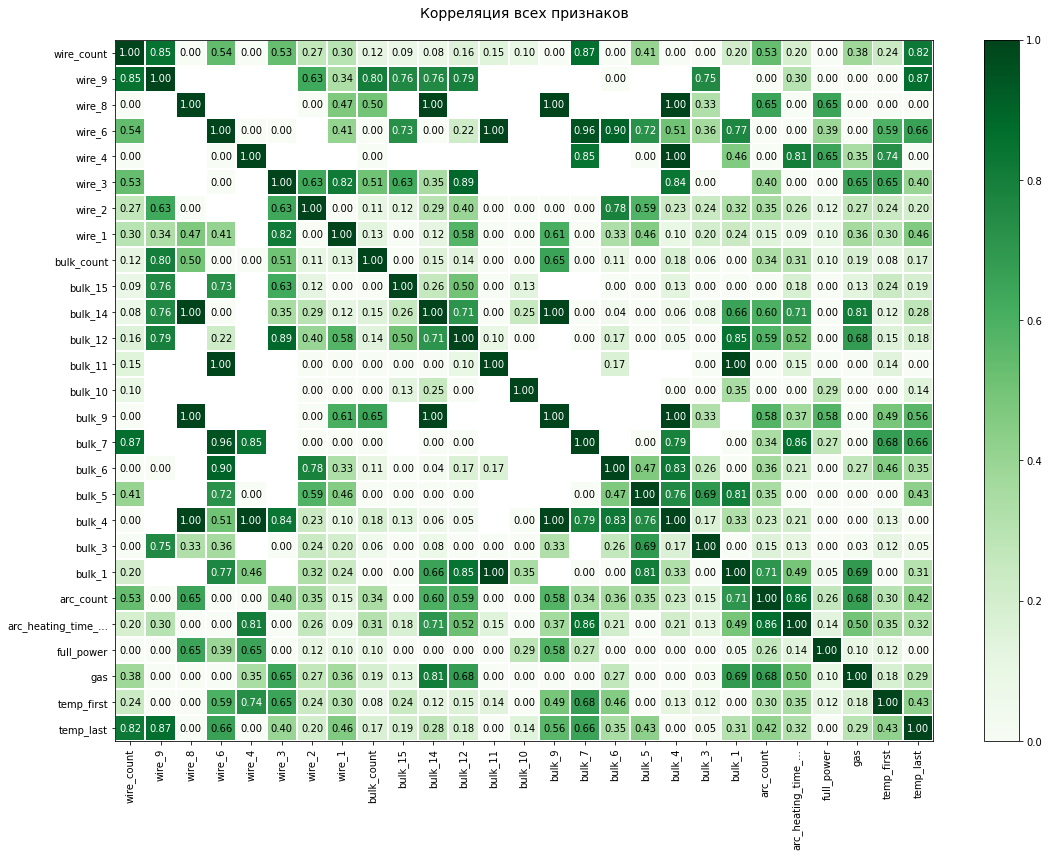

In [91]:
# т.к. количество возможных вариантов добавленных признаков количества нагревов и материалов мало, 
# отнесу их к категориальным признакам
interval_cols = df_final.drop(['wire_count', 'bulk_count', 'arc_count'], axis=1).columns

phik_overview = phik_matrix(df_final.drop(['bulk_8', 'bulk_2', 'bulk_13', 
                                           'wire_5', 'wire_7'], axis=1), interval_cols=interval_cols)
# убраны малоиспользуемые материалы
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title='Корреляция всех признаков\n',
    fontsize_factor=1.0,
    figsize=(16, 12)
)

Анализ отдельных признаков был выполнен в предыдущем шаге анализа данных. Так же в предыдущем шаге было выполнено добавление новых параметров. В данном шаге была оценена корреляция водных параметров с целевым и между друг другом. 

Между количеством нагревов и продолжительностью нагревов есть корреляция, можно будет убрать менее важный признак, если модель будет показывать плохой результат. Добавленный параметр Полная мощность не коррелирует с целевым  признаком, если при анализе важности признаков он окажется неважным, его можно исключить. Часть малоиспользуемых материалов не коррелирует с целевым признаком, можно попробовать объединить данные таких материалов, но т.к. их состав может быть очень разным, попробую обучить модели сначала на всех данных.

In [92]:
df_final

,temp_last,temp_first,gas,full_power,arc_heating_time_total,arc_count,bulk_1,bulk_2,bulk_3,bulk_4,...,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,wire_count
key,,,,,,,,,,,,,,,,,,,,,
1,1613.0,1571.0,29.749986,0.743747,1098.0,5,NaN,NaN,NaN,43.0,...,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,1602.0,1581.0,12.555561,0.647087,811.0,4,NaN,NaN,NaN,73.0,...,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,1599.0,1596.0,28.554793,1.003845,655.0,5,NaN,NaN,NaN,34.0,...,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,1625.0,1601.0,18.841219,0.850010,741.0,4,NaN,NaN,NaN,81.0,...,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
5,1602.0,1576.0,5.413692,0.704245,869.0,4,NaN,NaN,NaN,78.0,...,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,1591.0,1570.0,7.125735,0.967180,723.0,4,NaN,NaN,21.0,NaN,...,89.150879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2496,1591.0,1554.0,9.412616,0.845053,940.0,6,NaN,NaN,NaN,63.0,...,114.179527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2497,1589.0,1571.0,6.271699,1.453639,569.0,3,NaN,NaN,NaN,85.0,...,94.086723,9.04800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


## Подготовка данных

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    df_final.drop(['temp_last'], axis=1),
    df_final['temp_last'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE
)

print('Размеры тренировочной и тестовой выборок:')
X_train.shape, y_train.shape, X_test.shape, y_test.shape

Размеры тренировочной и тестовой выборок:


((1743, 31), (1743,), (582, 31), (582,))

In [94]:
num_columns = X_train.columns

num_pipe = Pipeline(
    [
        ('imputer', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=0, keep_empty_features=True)),
        ('scaler', StandardScaler())
    ]
)

data_preprocessor = ColumnTransformer(
    [
        ('num', num_pipe, num_columns)
    ],
    remainder='passthrough'
)
data_preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value=0,
                                                                keep_empty_features=True,
                                                                strategy='constant')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['temp_first', 'gas', 'full_power', 'arc_heating_time_total',
       'arc_count', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6',
       'bulk_7', 'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15', 'bulk_count', 'wire_1', 'wire_2',
       'wire_3', 'wire_4', 'wire_5', 'wire_6', 'wire_7', 'wire_8', 'wire_9',
       'wire_count'],
      dtype='object'))])

Выполнено разбиение данных на тренировочные и тестовые в соотношении 75/25 %. Для NaN значений, которые присутствуют в объёмах подаваемых материалов, было добавлено заполнение нулями. Для всех признаков, т.к. все являются числовыми, добавлено масштабирование.  

## Обучение моделей машинного обучения

Проверка значения MAE на dummy моделе:

In [95]:
X, X_v, y, y_v = train_test_split(
    X_train,
    y_train,
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE)

print('Размеры тренировочной и валидационной выборок:')
print(X.shape, X_v.shape)
print(y.shape, y_v.shape)

pipe_final_dummy = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DummyRegressor())
    ]
)
pipe_final_dummy.fit(X, y)
y_pred_dummy = pipe_final_dummy.predict(X_v)
print(f'Метрика MAE на валидационной выборке для Dummy модели: {round(MAE(y_v, y_pred_dummy), 3)}')

Размеры тренировочной и валидационной выборок:
(1307, 31) (436, 31)
(1307,) (436,)
Метрика MAE на валидационной выборке для Dummy модели: 8.156


In [96]:
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('model', LinearRegression())
    ]
)

search_params = [
    {
        'preprocessor__num__scaler': [StandardScaler()],
        'model': [LinearRegression()]
    },
    {
        'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), 'passthrough'],
        'model': [RandomForestRegressor(random_state=RANDOM_STATE)],
        'model__n_estimators': [5, 10, 30, 50],
        'model__max_depth': [5, 10, 20],
        'model__min_samples_split': range(2, 5)
    },
    {
        'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), 'passthrough'],
        'model': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'model__max_depth': [5, 10],
        'model__min_samples_split': range(2, 15, 5)
    },
    {
        'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), 'passthrough'],
        'model': [KNeighborsRegressor()],
        'model__n_neighbors': [3, 7, 11]
    },
    {
        'preprocessor__num__scaler': [StandardScaler()],
        'model': [SGDRegressor()],
        'model__penalty': ['l2', 'l1'],
        'model__alpha': [0.01, 0.1, 0.5],
        'model__max_iter': range(4, 15, 2)
    },
    {
        'preprocessor__num__scaler': [StandardScaler()],
        'model': [SVR()],
        'model__kernel': ['linear', 'poly', 'rbf'],
        'model__max_iter': range(4, 15, 2)
    }
]

In [97]:
rs = GridSearchCV(
    pipe_final,
    search_params,
    n_jobs=-1,
    cv=5,
    scoring='neg_mean_absolute_error'#,
#    n_iter=150,
#    verbose=10,
#    random_state=RANDOM_STATE
)

start = time.time()
rs.fit(X_train, y_train)

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value=0,
                                                                                                        keep_empty_features=True,
                                                                                                        strategy='constant')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['temp_first', 'gas', 'full_power', 'arc_heating_time_total',
       'arc_count', 'bulk_1', 'bulk_2', 'b...
                                                        'passthrough']},
                         {'model': [SGDRegressor()],
                          'model__alpha': [0.01, 0.1, 0.5],
                          'model__max_iter': range(4, 15, 2),
                          'model__penalty': ['l2', 'l1'],
                          'preprocessor__num__scaler': [StandardScaler()]},
                         {'model': [SVR()],
                          'model__kernel': ['linear', 'poly', 'rbf'],
                          'model__max_iter': range(4, 15, 2),
                          'preprocessor__num__scaler': [StandardScaler()]}],
             scoring='neg_mean_absolute_error')

In [98]:
print(f'Время выбора и обучения моделей: {(time.time() - start):.3f} сек.')
print()
print('Лучшая модель и её параметры:\n', rs.best_estimator_)
print()
print('Метрика лучшей модели на кросс валидационной выборке:', rs.best_score_ * -1)

Время выбора и обучения моделей: 184.989 сек.

Лучшая модель и её параметры:
 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 keep_empty_features=True,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['temp_first', 'gas', 'full_power', 'arc_heating_time_total',
       'arc_count', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6',
       'bulk_7', 'bulk_8'

In [99]:
rs_results = pd.DataFrame(rs.cv_results_).sort_values(by='rank_test_score')
rs_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model,param_preprocessor__num__scaler,param_model__max_depth,param_model__min_samples_split,param_model__n_estimators,param_model__n_neighbors,...,param_model__kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.156791,0.054525,0.098280,0.053636,LinearRegression(),StandardScaler(),NaN,NaN,NaN,NaN,...,NaN,"{'model': LinearRegression(), 'preprocessor__n...",-6.667197,-6.123721,-6.318663,-5.640419,-6.860039,-6.322008,0.427206,1
45,0.317966,0.011303,0.012209,0.000617,RandomForestRegressor(random_state=61125),passthrough,10.0,2.0,30.0,NaN,...,NaN,{'model': RandomForestRegressor(random_state=6...,-6.994935,-6.199007,-6.607132,-5.846036,-6.455094,-6.420441,0.386024,2
44,0.320916,0.006416,0.012533,0.000438,RandomForestRegressor(random_state=61125),MinMaxScaler(),10.0,2.0,30.0,NaN,...,NaN,{'model': RandomForestRegressor(random_state=6...,-7.000959,-6.196228,-6.602210,-5.849320,-6.455750,-6.420893,0.386714,3
48,0.528353,0.018434,0.015445,0.001397,RandomForestRegressor(random_state=61125),passthrough,10.0,2.0,50.0,NaN,...,NaN,{'model': RandomForestRegressor(random_state=6...,-6.915761,-6.175979,-6.650507,-5.904630,-6.477751,-6.424926,0.354197,4
47,0.525108,0.016551,0.015230,0.000454,RandomForestRegressor(random_state=61125),MinMaxScaler(),10.0,2.0,50.0,NaN,...,NaN,{'model': RandomForestRegressor(random_state=6...,-6.920923,-6.173733,-6.645098,-5.904249,-6.481929,-6.425187,0.355511,5


In [100]:
rs_results['param_model'].unique()

array([LinearRegression(), RandomForestRegressor(random_state=61125),
       SGDRegressor(), KNeighborsRegressor(),
       DecisionTreeRegressor(random_state=61125), SVR()], dtype=object)

Были обучены модели LinearRegression(), SGDRegressor(), RandomForestRegressor(random_state=61125), KNeighborsRegressor(), DecisionTreeRegressor(random_state=61125), SVR() с подбором гиперпараметров. Наилучшее значение метрики MAE на кросс-валидационной выборке показала модель LinearRegression() со значением 6.322. Достигается условие проекта MAE ≤ 6.8.

## Проверка лучшей модели на тестовой выборке

In [101]:
y_test_pred = rs.predict(X_test)
print(f'Метрика MAE на тестовой выборке: {round(MAE(y_test, y_test_pred), 3)}')

Метрика MAE на тестовой выборке: 6.241


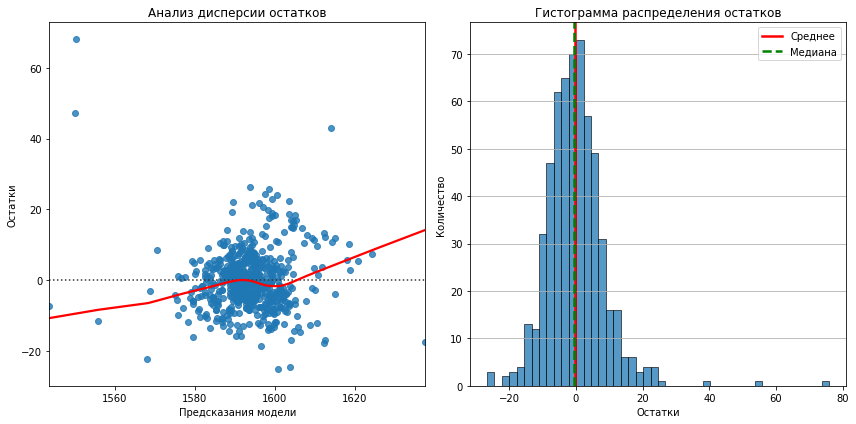

In [102]:
# анализ остатков
residuals = y_test - y_test_pred

fig, (ax_res, ax_hist) = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
sns.residplot(x=y_test_pred, y=residuals, lowess=True, line_kws=dict(color="r"), ax=ax_res)
ax_res.set_title('Анализ дисперсии остатков')
ax_res.set_xlabel('Предсказания модели')
ax_res.set_ylabel('Остатки')

sns.histplot(x=residuals, ax=ax_hist)
ax_hist.axvline(residuals.mean(), c='red', ls='-', lw=2.5, label='Среднее')
ax_hist.axvline(residuals.median(), c='green', ls='--', lw=2.5, label='Медиана')
ax_hist.set_xlabel('Остатки')
ax_hist.set_ylabel('Количество')
ax_hist.set_title('Гистограмма распределения остатков')
ax_hist.legend()
ax_hist.grid(axis='y')
fig.tight_layout()
plt.show()

Модель LinearRegression() показала значение MAE на тестовой выборке: 6.241. Распределение остатков нормальное, но есть выбросы, из-за котороых дисперсия не равномерна. Для улучшения дисперсии остатков можно попробовать дополнительно проработать входные признаки - объединить малоиспользуемые материалы или вывести новые признаки из существующих параметров или запросить детали по добавляемым материалам.

## Анализ важности признаков

In [103]:
model_coef = pd.DataFrame({'feature_name': rs.feature_names_in_, 
                           'coef': rs.best_estimator_.named_steps['model'].coef_})
model_coef.sort_values('coef', ascending=False)

,feature_name,coef
3,arc_heating_time_total,7.878353e+00
0,temp_first,5.702875e+00
13,bulk_9,2.934552e+00
19,bulk_15,1.243562e+00
21,wire_1,1.039623e+00
6,bulk_2,5.035290e-01
16,bulk_12,4.919268e-01
8,bulk_4,3.569504e-01
14,bulk_10,1.807703e-01
7,bulk_3,1.589412e-01


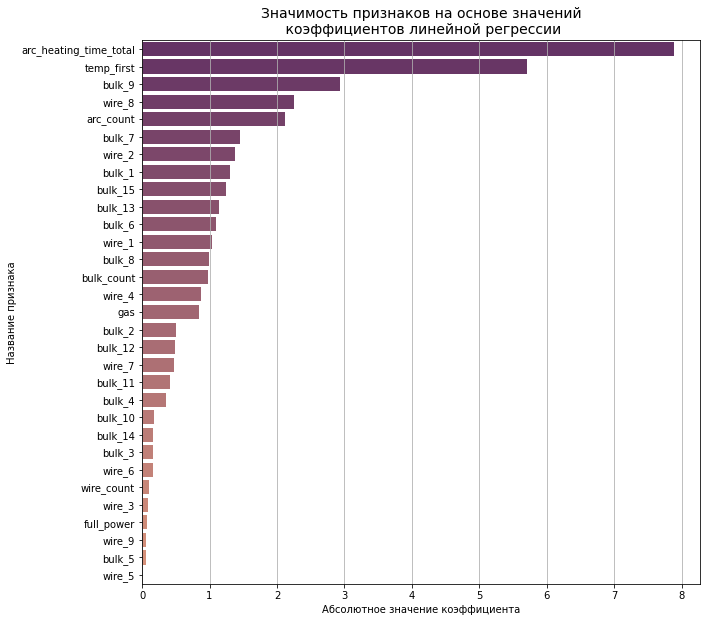

In [104]:
model_coef['coef_abs'] = np.abs(model_coef['coef'])
model_coef = model_coef.set_index('feature_name')

plt.figure(figsize = (10, 10))
sns.barplot(data=model_coef.sort_values('coef_abs', ascending=False), 
            x='coef_abs', 
            y=model_coef.sort_values('coef_abs', ascending=False).index, 
            palette='blend:#6c2b6d,#e98d6b')
plt.title('Значимость признаков на основе значений\n коэффициентов линейной регрессии', fontsize=14)
plt.xlabel('Абсолютное значение коэффициента')
plt.ylabel('Название признака')
plt.grid(axis='x')
plt.show()

Наибольшее влияние на предсказание модели оказывают признаки:
- продолжительность нагрева дугой
- температура первого замера
- объём сыпучего материала Bulk 9
- объём проволочного материала Wire 8
- количество наревов дугой

Не влияют или практически не влияют признаки (значения коэффициентов меньше единицы, т.е. модель снижает их значимость при вычислении целевого признака):
- объём материалов, которые редко встречаются в получнных данных
- полная мощность
- количество типов добавленных проволочных материалов

## Общий вывод и рекомендации заказчику

### Рекомендации заказчику

На итоговую температуру партии наиболее значимыми являются параметры (расположены по уменьшению значимости):
- продолжительность нагрева дугой
- температура первого замера
- объём сыпучего материала Bulk 9
- объём проволочного материала Wire 8
- количество наревов дугой
- объём сыпучего материала Bulk 7
- объём проволочного материала Wire 2
- объём сыпучего материала Bulk 1
- объём сыпучего материала Bulk 15
- объём сыпучего материала Bulk 13
- объём сыпучего материала Bulk 6

Для уменьшения потребление электроэнергии на этапе обработки стали комбинату по возможности нужно планировать и настраивать продолжительность нагрева сплава, температуру, с которой сплав был подан, объёмы вводимых материалов.

### Отчёт

**Ответы на вопросы:**
1. Какие пункты	плана были выполнены, а какие нет
> Все пункты плана были выполнены.
В ходе работы было сделано:
>- Загрузка данных из всех файлов и выполнение их первичного осмотра.
>- Исследовательский анализ и предобработка данных для выбора параметров для обучения модели: проведён анализ признаков, визуализация распределений признаков, выявлены и устранены аномальные выбросы, сгенерированы новые признаки для использования в моделях, убраны ненужные признаки.
>- Выбор параметров для обучения моделей и объединение их в общий датафрейм: в общий датафрейм попали только те партии, которые присутствовали во всех данных и по которым была известна температура последнего замера - т.е. значение целевого признака.
>- Исследовательский анализ и предобработка данных объединённого датафрейма: т.к. основной анализ был выполнен на шаге 2, на данном шаге был выполнен корреляционный анализ.
>- Подготовка данных: разделение данных на две выборки, масштабирование признаков и создание пайплайна.
>- Обучение моделей машинного обучения: обучение моделей LinearRegression(), SGDRegressor(), RandomForestRegressor(), KNeighborsRegressor(), DecisionTreeRegressor(), SVR() с подбором гиперпараметров и выбор модели с наименьшим значением метрики MAE на кросс-валидационной выборке. Модель LinearRegression() показала наилучший результат со значением MAE на кросс-валидационной выборке 6,322.
>- Выбор лучшей модели: проверка качества лучшей модели на тестовой выборке и анализ остатков. На тестовой выборке выбранная модель LinearRegression() показала занчение MAE 6,241.
>- Общий вывод и рекомендации заказчику

2. Какие трудности возникли и как вы их преодалели?
> Не могу сказать, что были именно трудности. Просто анализ данных занял время. Зато обработанные и выбранные параметры сразу показали значение MAE 6,3.

3. Какие ключевые шаги в решении задачи выделили?
> Погружение в область и обработка данных

**Список признаков, используемых для обучения лучшей модели и описание их предобработки.** <br>
- 'temp_first' - температура первого замера партии; была взята из файла data_temp_new.csv из значения Температура для первого значения Время замера по key; из данных были удалены значения температур ниже 1400 как некорректные.
- 'gas' - объём газа, подаваемого при продувге сплава; было взято значение из файла data_gas_new.csv; в общих данных были оставлены только те партии, которые имели значение Газ.
- 'full_power' - полная мощность; добавленный параметр, который был вычеслен из значений активной и реактивной мощностей, указанных в файле data_arc_new.csv; в ходе анализа значений мощностей был выявлен и устранён аномальный выброс реактивной мощности.
- 'arc_heating_time_total' - общее время нагрева дугой; добавленный параметр, который был вычеслен как суммарное время в секндах между Конец нагрева дугой и Начало нагрева дугой для каждого key, взятых из файла data_arc_new.csv.
- 'arc_count' - общее количество нагревов дугой; добавленный параметр, который был вычеслен как количество нагревов для каждого key, взятых из файла data_arc_new.csv.
- 'bulk_1' ... 'bulk_15' - объём сыпучих материалов; значения были взяты из файла data_bulk_new.csv, при этом время подачи материалов из файла data_bulk_time_new.csv было убрано из признаков; были оставлены все материалы, т.к. их состав и влияние на сплав неизвестны (нет уверенности, что объединение значений будет корректно).
- 'bulk_count' - количество добавленных сыпучих материалов; добавленный параметр, который был вычеслен как количество типов добавленных сыпучих материалов для партии.
- 'wire_1' ... 'wire_9' - объём проволочных материалов; значения были взяты из файла data_wire_new.csv, при этом время подачи материалов из файла data_wire_time_new.csv было убрано из признаков; были оставлены все материалы, т.к. их состав и влияние на сплав неизвестны (нет уверенности, что объединение значений будет корректно).
- 'wire_count' - количество добавленных проволочных материалов; добавленный параметр, который был вычеслен как количество типов добавленных проволочных материалов для партии.

**Гиперпараметры лучшей модели, включая random_state (если  имеется у модели).** <br>
Была выбрана модель LinearRegression(), которая не имеет гиперпараметров.

**Что рекомендуете для улучшения модели, решения** <br>
Для улучшения качества модели можно попробовать дополнительно проработать входные признаки - объединить малоиспользуемые материалы или вывести новые признаки из существующих параметров или запросить детали по добавляемым материалам.